# Scenario 1: Brain Stroke Prediction using Machine Learning Classification

## Project objective

The objective of this notebook is to build and evaluate a machine learning classification model to predict the target variable `stroke`.

The dataset is highly imbalanced, so accuracy alone is not used to select the final model. The main model selection metric is **F1-score**, because the modelling objective is to balance precision and recall.

This notebook includes the following pipeline:

1. Load and inspect the data
2. Define preprocessing decisions
3. Perform exploratory data analysis
4. Test feature engineering
5. Compare multiple classification models, handle class imbalance using class weights and random oversampling
6. Use out-of-fold predictions for model and threshold selection
7. Tune selected model families
8. Evaluate the final model on an internal test set
9. Produce the required predictions CSV for the unseen data

## 1.1 Import libraries

In [2]:
from pathlib import Path
import inspect
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import RandomOverSampler
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn is not installed. Random oversampling models will be skipped.")
    print("Install with: pip install imbalanced-learn")

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 1.2 File paths

The processed datasets are expected to be stored in the project folder structure below.

```text
Processed_datasets/
    Brain Stroke/
        brain_stroke_data.csv
        brain_stroke_unseen.csv
```

The predictions file is saved in the same folder as the training data.

In [12]:
TRAIN_PATH = "Processed_datasets/Brain Stroke/brain_stroke_data.csv"
UNSEEN_PATH = "Processed_datasets/Brain Stroke/brain_stroke_unseen.csv"

PREDICTIONS_PATH = "Fenner_Backhouse_scenario_1.csv"

print("Training path:", TRAIN_PATH)
print("Unseen path:", UNSEEN_PATH)
print("Predictions output path:", PREDICTIONS_PATH)

Training path: Processed_datasets/Brain Stroke/brain_stroke_data.csv
Unseen path: Processed_datasets/Brain Stroke/brain_stroke_unseen.csv
Predictions output path: Fenner_Backhouse_scenario_1.csv


## 1.3 Load the data

In [17]:
train_df = pd.read_csv(TRAIN_PATH)
unseen_df = pd.read_csv(UNSEEN_PATH)

print("Training data shape:", train_df.shape)
print("Unseen data shape:", unseen_df.shape)

display(train_df.head())
display(unseen_df.head())

Training data shape: (4482, 11)
Unseen data shape: (499, 10)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,0
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Female,49.0,0,0,Yes,Private,Rural,56.11,28.7,smokes
1,Male,75.0,0,0,Yes,Private,Rural,75.47,24.5,formerly smoked
2,Female,71.0,0,0,Yes,Private,Rural,100.61,19.2,Unknown
3,Female,12.0,0,0,No,children,Rural,85.97,35.7,Unknown
4,Male,63.0,0,0,Yes,Private,Rural,104.79,24.1,Unknown


## 2.1 Initial data checks

The initial checks confirm whether the data structure matches the classification task.

In [20]:
TARGET = "stroke"

assert TARGET in train_df.columns, "The training dataset must contain the target column."
assert TARGET not in unseen_df.columns, "The unseen dataset should not contain the target column."

feature_cols = [col for col in train_df.columns if col != TARGET]

assert set(feature_cols) == set(unseen_df.columns), "Training and unseen feature columns do not match."

# Align unseen column order to training feature order.
unseen_df = unseen_df[feature_cols]

print("Training data information:")
train_df.info()

print("\nMissing values in training data:")
display(train_df.isna().sum())

print("Missing values in unseen data:")
display(unseen_df.isna().sum())

print("Duplicate rows in training data:", train_df.duplicated().sum())
print("Duplicate rows in unseen data:", unseen_df.duplicated().sum())

assert train_df.isna().sum().sum() == 0, "Training data contains missing values."
assert unseen_df.isna().sum().sum() == 0, "Unseen data contains missing values."

Training data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4482 entries, 0 to 4481
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4482 non-null   object 
 1   age                4482 non-null   float64
 2   hypertension       4482 non-null   int64  
 3   heart_disease      4482 non-null   int64  
 4   ever_married       4482 non-null   object 
 5   work_type          4482 non-null   object 
 6   Residence_type     4482 non-null   object 
 7   avg_glucose_level  4482 non-null   float64
 8   bmi                4482 non-null   float64
 9   smoking_status     4482 non-null   object 
 10  stroke             4482 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 385.3+ KB

Missing values in training data:


gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Missing values in unseen data:


gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
dtype: int64

Duplicate rows in training data: 0
Duplicate rows in unseen data: 0


### Data cleaning decisions

No imputation is applied because both the labelled training data and unseen data contain no missing values.

No duplicate rows are removed because no duplicate rows are present.

The value `Unknown` in `smoking_status` is retained as a valid category because it appears frequently and may contain information about the data collection process.

## 2.2 Target distribution

The target variable is checked before modelling because the dataset is imbalanced.

Target counts:


stroke
0    4259
1     223
Name: count, dtype: int64

Target percentages:


stroke
0    95.02
1     4.98
Name: proportion, dtype: float64

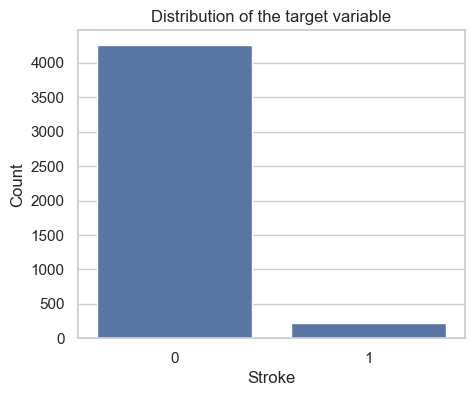

In [24]:
target_counts = train_df[TARGET].value_counts()
target_percentages = train_df[TARGET].value_counts(normalize=True) * 100

print("Target counts:")
display(target_counts)

print("Target percentages:")
display(target_percentages.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(data=train_df, x=TARGET)
plt.title("Distribution of the target variable")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

### Target distribution interpretation

The positive stroke class is much smaller than the non-stroke class. This means a model can achieve high accuracy by mainly predicting the majority class.

Accuracy is therefore reported, but model selection focuses on F1-score.

## 2.3 Define feature groups

The feature groups are defined manually so that preprocessing decisions are explicit.

In [28]:
continuous_features = [
    "age",
    "avg_glucose_level",
    "bmi",
]

binary_features = [
    "hypertension",
    "heart_disease",
]

categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
]

all_grouped_features = continuous_features + binary_features + categorical_features

assert set(all_grouped_features) == set(feature_cols), "Some features are missing from the feature groups."

print("Continuous features:", continuous_features)
print("Binary features:", binary_features)
print("Categorical features:", categorical_features)

Continuous features: ['age', 'avg_glucose_level', 'bmi']
Binary features: ['hypertension', 'heart_disease']
Categorical features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


## 3 Exploratory data analysis

The exploratory data analysis focuses on summaries and plots that support modelling decisions.

### 3.1 Numerical feature summaries

In [34]:
display(train_df[continuous_features].describe())

,age,avg_glucose_level,bmi
count,4482.000000,4482.000000,4482.000000
mean,43.446693,105.761430,28.466064
std,22.592327,44.943627,6.764658
min,0.080000,55.120000,14.000000
25%,26.000000,77.192500,23.600000
50%,45.000000,91.680000,28.100000
75%,61.000000,113.637500,32.575000
max,82.000000,267.760000,48.900000


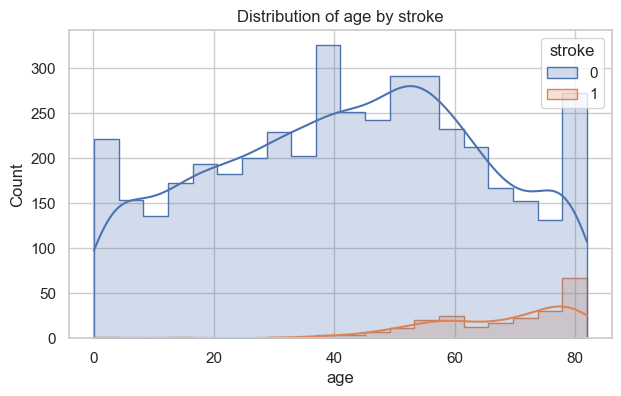

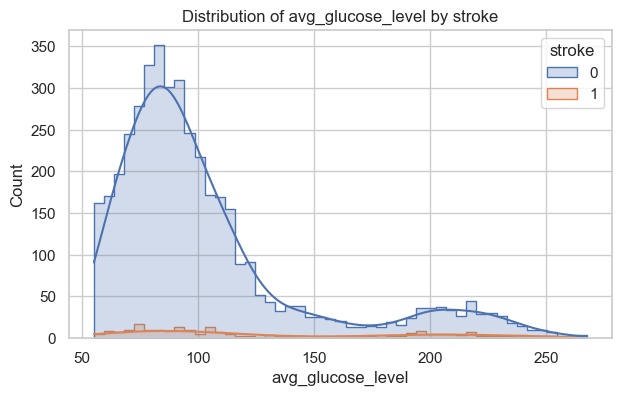

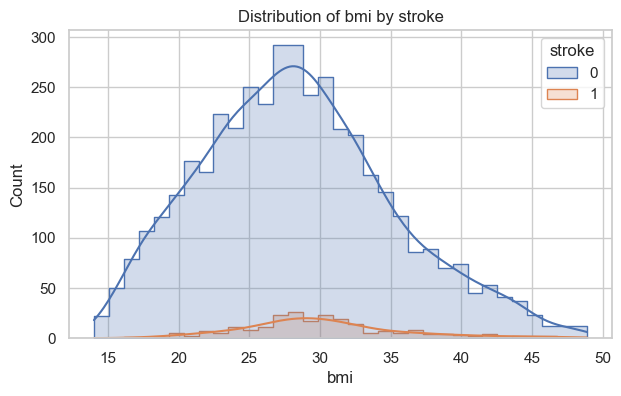

In [38]:
for col in continuous_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=train_df, x=col, hue=TARGET, kde=True, element="step")
    plt.title(f"Distribution of {col} by stroke")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

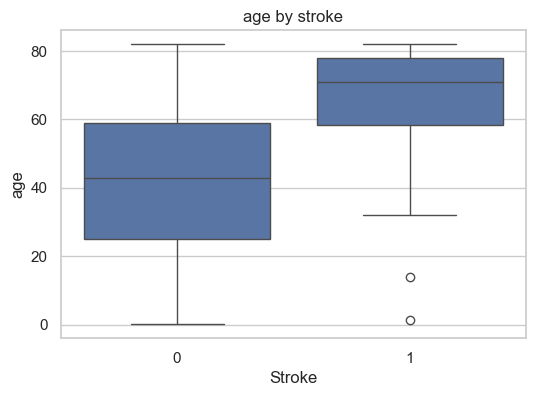

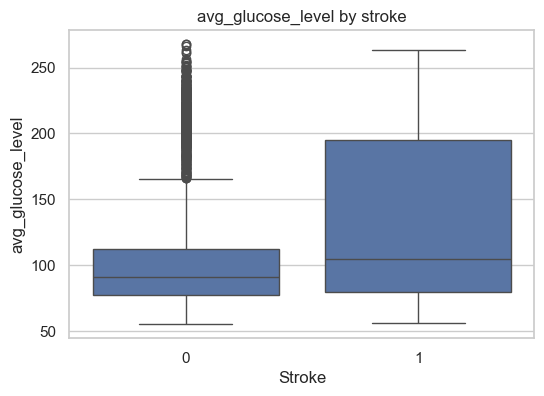

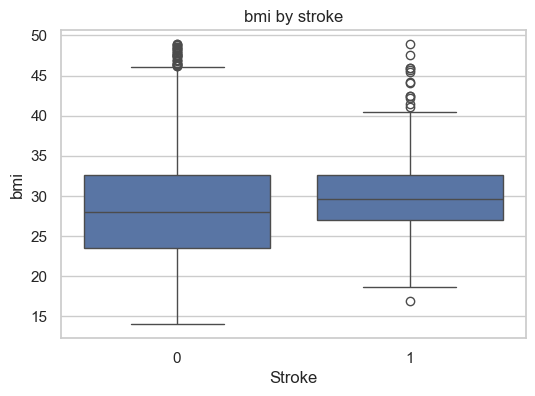

In [40]:
for col in continuous_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=train_df, x=TARGET, y=col)
    plt.title(f"{col} by stroke")
    plt.xlabel("Stroke")
    plt.ylabel(col)
    plt.show()

### Numerical feature interpretation

Age shows clear separation between the stroke and non-stroke groups. Glucose level and BMI may also contribute, although the class separation is limited. This supports the use of models that can combine several weak predictors.

### 3.2 Categorical feature summaries

Value counts for gender:


gender
Female    2600
Male      1882
Name: count, dtype: int64

stroke,0,1
gender,,
Female,0.951538,0.048462
Male,0.948459,0.051541


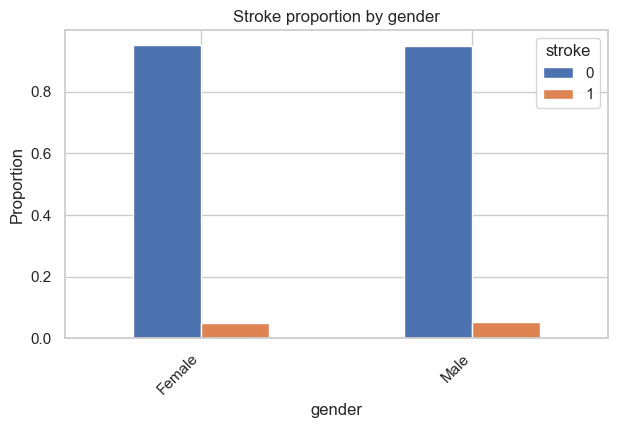

Value counts for ever_married:


ever_married
Yes    2951
No     1531
Name: count, dtype: int64

stroke,0,1
ever_married,,
No,0.983671,0.016329
Yes,0.932904,0.067096


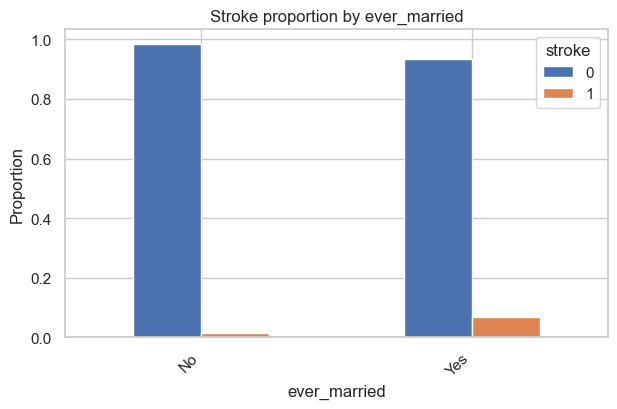

Value counts for work_type:


work_type
Private          2571
Self-employed     721
children          602
Govt_job          588
Name: count, dtype: int64

stroke,0,1
work_type,,
Govt_job,0.948980,0.051020
Private,0.949436,0.050564
Self-employed,0.915395,0.084605
children,0.996678,0.003322


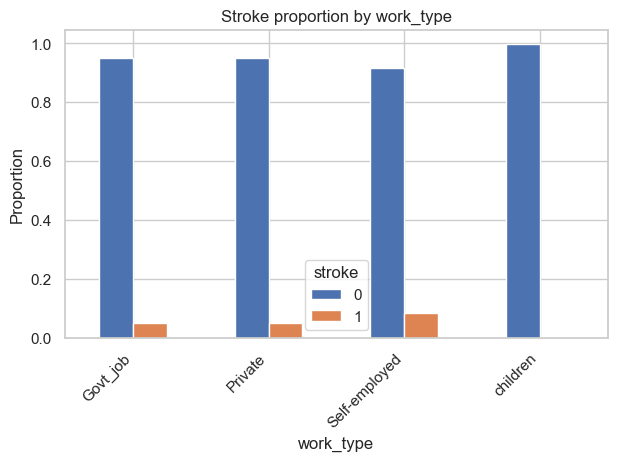

Value counts for Residence_type:


Residence_type
Urban    2282
Rural    2200
Name: count, dtype: int64

stroke,0,1
Residence_type,,
Rural,0.954091,0.045909
Urban,0.946538,0.053462


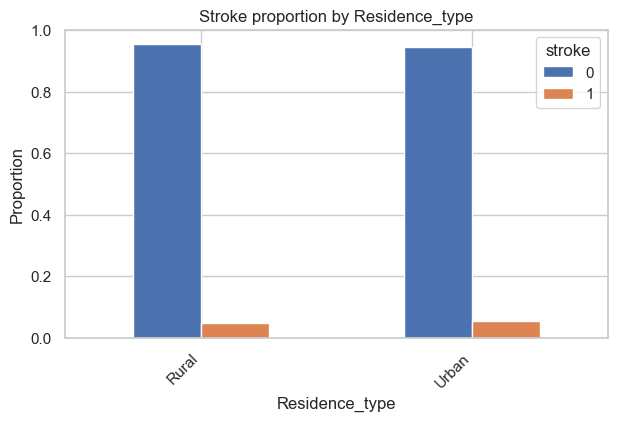

Value counts for smoking_status:


smoking_status
never smoked       1665
Unknown            1352
formerly smoked     759
smokes              706
Name: count, dtype: int64

stroke,0,1
smoking_status,,
Unknown,0.968195,0.031805
formerly smoked,0.918314,0.081686
never smoked,0.952553,0.047447
smokes,0.944759,0.055241


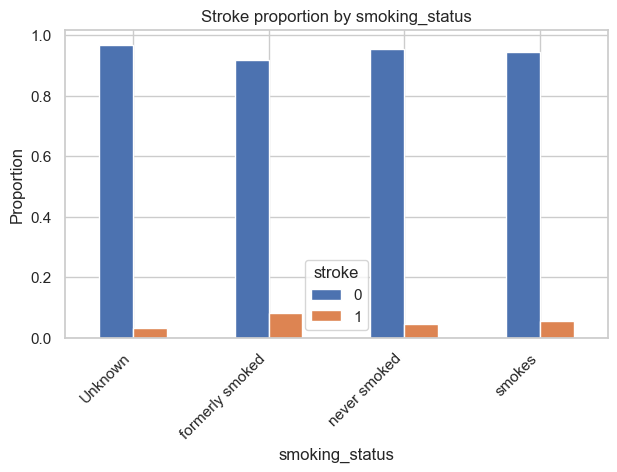

In [46]:
for col in categorical_features:
    print(f"Value counts for {col}:")
    display(train_df[col].value_counts(dropna=False))

    stroke_rate_table = pd.crosstab(train_df[col], train_df[TARGET], normalize="index")
    display(stroke_rate_table)

    stroke_rate_table.plot(kind="bar", figsize=(7, 4))
    plt.title(f"Stroke proportion by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.xticks(rotation=45, ha="right")
    plt.show()

### Categorical feature interpretation

The categorical variables show different stroke proportions across groups. These variables are retained and one-hot encoded. The `Unknown` category in `smoking_status` is retained as a separate category.

### 3.3 Binary medical features

stroke,0,1
hypertension,,
0,0.959169,0.040831
1,0.868481,0.131519


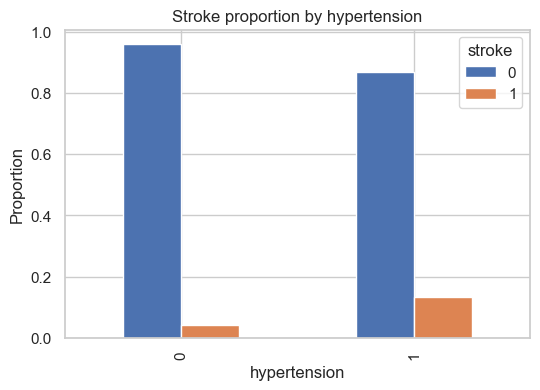

stroke,0,1
heart_disease,,
0,0.957045,0.042955
1,0.832653,0.167347


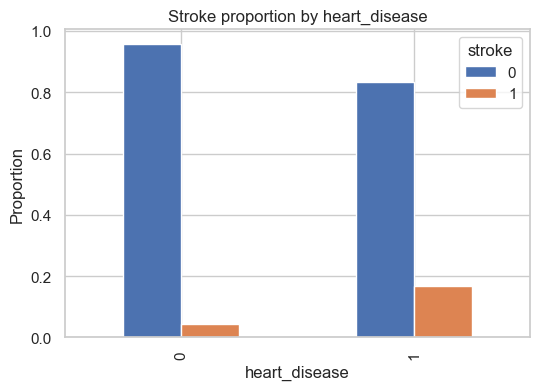

In [50]:
for col in binary_features:
    stroke_rate_table = pd.crosstab(train_df[col], train_df[TARGET], normalize="index")
    display(stroke_rate_table)

    stroke_rate_table.plot(kind="bar", figsize=(6, 4))
    plt.title(f"Stroke proportion by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.show()

### Binary feature interpretation

Hypertension and heart disease show higher stroke proportions for positive risk groups. They are kept as binary 0 and 1 variables.

### 3.4 Correlation analysis

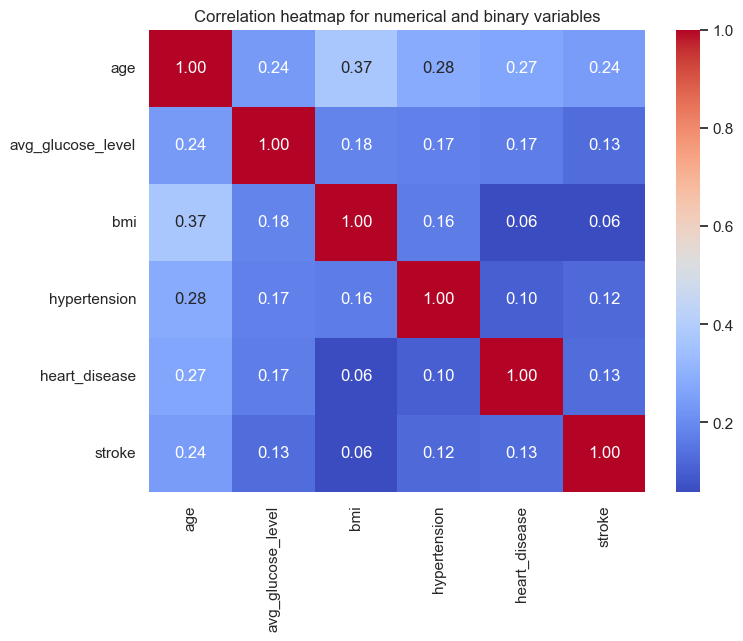

In [55]:
corr_cols = continuous_features + binary_features + [TARGET]

plt.figure(figsize=(8, 6))
sns.heatmap(train_df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap for numerical and binary variables")
plt.show()

In [57]:
feature_corr = train_df[continuous_features + binary_features].corr().abs()

upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
    .rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: "Absolute correlation"})
    .sort_values("Absolute correlation", ascending=False)
)

display(high_corr_pairs)

print("Feature pairs with absolute correlation above 0.85:")
display(high_corr_pairs[high_corr_pairs["Absolute correlation"] > 0.85])

,Feature 1,Feature 2,Absolute correlation
1,age,bmi,0.368143
2,age,hypertension,0.279843
3,age,heart_disease,0.268319
0,age,avg_glucose_level,0.236010
4,avg_glucose_level,bmi,0.180692
5,avg_glucose_level,hypertension,0.174468
6,avg_glucose_level,heart_disease,0.166204
7,bmi,hypertension,0.163971
9,hypertension,heart_disease,0.101804
8,bmi,heart_disease,0.061354


Feature pairs with absolute correlation above 0.85:


,Feature 1,Feature 2,Absolute correlation


### Correlation interpretation

No original variables are removed based only on correlation. The original feature set is small, and there are no strongly redundant numerical or binary predictors based on the correlation check.

A feature would only be considered for removal if it was extremely correlated with another input feature and if removing it improved F1-score.

## 4. Feature engineering

Feature engineering is tested as a controlled model variant.

The engineered features are used in the final model only if they improve out-of-fold F1-score.

In [61]:
def add_engineered_features(df):
    df = df.copy()

    df["medical_risk_count"] = df["hypertension"] + df["heart_disease"]
    df["age_hypertension"] = df["age"] * df["hypertension"]
    df["age_heart_disease"] = df["age"] * df["heart_disease"]
    df["glucose_bmi_ratio"] = df["avg_glucose_level"] / (df["bmi"] + 1)

    df["age_group"] = pd.cut(
        df["age"],
        bins=[-np.inf, 18, 40, 60, np.inf],
        labels=["child", "young_adult", "middle_aged", "older_adult"]
    ).astype(str)

    df["bmi_group"] = pd.cut(
        df["bmi"],
        bins=[-np.inf, 18.5, 25, 30, np.inf],
        labels=["low_bmi", "normal_bmi", "overweight", "high_bmi"]
    ).astype(str)

    return df


feature_engineer = FunctionTransformer(add_engineered_features, validate=False)

engineered_continuous_features = continuous_features + [
    "medical_risk_count",
    "age_hypertension",
    "age_heart_disease",
    "glucose_bmi_ratio",
]

engineered_binary_features = binary_features

engineered_categorical_features = categorical_features + [
    "age_group",
    "bmi_group",
]

engineered_preview = add_engineered_features(train_df.drop(columns=[TARGET]))
display(engineered_preview.head())

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,medical_risk_count,age_hypertension,age_heart_disease,glucose_bmi_ratio,age_group,bmi_group
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0,0.0,0.0,1.815438,middle_aged,high_bmi
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0,0.0,0.0,8.865714,older_adult,overweight
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,1,70.0,0.0,4.400370,older_adult,overweight
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0,0.0,0.0,3.223055,middle_aged,high_bmi
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0,0.0,0.0,2.092357,young_adult,high_bmi


## 5.1 Train-test split

The data is split into:

- `X_train_full`, used for model comparison, threshold selection and final training
- `X_test`, kept untouched for the final internal evaluation

A stratified split is used to preserve the class proportion.

In [64]:
X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training split shape:", X_train_full.shape)
print("Test split shape:", X_test.shape)

print("Training target distribution:")
display(y_train_full.value_counts(normalize=True).round(4))

print("Test target distribution:")
display(y_test.value_counts(normalize=True).round(4))

Training split shape: (3585, 10)
Test split shape: (897, 10)
Training target distribution:


stroke
0    0.9503
1    0.0497
Name: proportion, dtype: float64

Test target distribution:


stroke
0    0.9498
1    0.0502
Name: proportion, dtype: float64

## 5.2 Preprocessing

The preprocessing does not include imputation.

The preprocessing steps are:

1. Scale continuous variables
2. Pass binary variables through unchanged
3. One-hot encode categorical variables

In [67]:
def make_one_hot_encoder():
    params = {"handle_unknown": "ignore"}

    if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
        params["sparse_output"] = False
    else:
        params["sparse"] = False

    return OneHotEncoder(**params)


base_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_features),
        ("bin", "passthrough", binary_features),
        ("cat", make_one_hot_encoder(), categorical_features),
    ],
    remainder="drop",
)

engineered_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), engineered_continuous_features),
        ("bin", "passthrough", engineered_binary_features),
        ("cat", make_one_hot_encoder(), engineered_categorical_features),
    ],
    remainder="drop",
)

## 5.3 Out-of-fold model evaluation

Out-of-fold predictions are used to compare models and tune the classification threshold.

Each row in the training set is predicted by a model that was not trained on that row. This gives a fair basis for threshold tuning.

The threshold is selected to maximise F1-score.

In [71]:
def make_standard_pipeline(preprocessor, classifier):
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ])


def make_oversampling_pipeline(preprocessor, sampler, classifier):
    if not IMBLEARN_AVAILABLE:
        return None

    return ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", sampler),
        ("classifier", classifier),
    ])


def add_model(model_dict, name, model):
    if model is not None:
        model_dict[name] = model


def get_positive_scores(fitted_model, X_data):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X_data)[:, 1]

    if hasattr(fitted_model, "decision_function"):
        scores = fitted_model.decision_function(X_data)
        return (scores - scores.min()) / (scores.max() - scores.min())

    raise ValueError("Model does not provide probability scores or decision scores.")


def threshold_search(y_true, y_scores, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    rows = []

    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)

        rows.append({
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
        })

    threshold_df = pd.DataFrame(rows)

    best_row = (
        threshold_df
        .sort_values(["F1", "Precision", "Recall"], ascending=False)
        .iloc[0]
    )

    return float(best_row["Threshold"]), threshold_df


def evaluate_scores(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_scores),
        "PR_AUC": average_precision_score(y_true, y_scores),
    }


def get_oof_scores(model, X_data, y_data, cv):
    oof_scores = np.zeros(len(X_data))

    for train_idx, valid_idx in cv.split(X_data, y_data):
        X_fold_train = X_data.iloc[train_idx]
        X_fold_valid = X_data.iloc[valid_idx]
        y_fold_train = y_data.iloc[train_idx]

        fold_model = clone(model)
        fold_model.fit(X_fold_train, y_fold_train)

        oof_scores[valid_idx] = get_positive_scores(fold_model, X_fold_valid)

    return oof_scores


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

## 5.4 Define candidate models

The model set includes a baseline, standard classification models, class-weighted models and random oversampling models.

In [73]:
candidate_models = {}

add_model(
    candidate_models,
    "Dummy baseline",
    make_standard_pipeline(
        base_preprocessor,
        DummyClassifier(strategy="most_frequent")
    )
)

add_model(
    candidate_models,
    "Logistic Regression",
    make_standard_pipeline(
        base_preprocessor,
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    )
)

add_model(
    candidate_models,
    "KNN",
    make_standard_pipeline(
        base_preprocessor,
        KNeighborsClassifier()
    )
)

add_model(
    candidate_models,
    "Decision Tree class_weight",
    make_standard_pipeline(
        base_preprocessor,
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
)

add_model(
    candidate_models,
    "Random Forest class_weight",
    make_standard_pipeline(
        base_preprocessor,
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
)

add_model(
    candidate_models,
    "Gradient Boosting",
    make_standard_pipeline(
        base_preprocessor,
        GradientBoostingClassifier(random_state=RANDOM_STATE)
    )
)

add_model(
    candidate_models,
    "SVM class_weight",
    make_standard_pipeline(
        base_preprocessor,
        SVC(
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        )
    )
)

if IMBLEARN_AVAILABLE:
    add_model(
        candidate_models,
        "Logistic Regression RandomOverSampler 0.5",
        make_oversampling_pipeline(
            base_preprocessor,
            RandomOverSampler(sampling_strategy=0.50, random_state=RANDOM_STATE),
            LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
        )
    )

    add_model(
        candidate_models,
        "Random Forest RandomOverSampler 0.5",
        make_oversampling_pipeline(
            base_preprocessor,
            RandomOverSampler(sampling_strategy=0.50, random_state=RANDOM_STATE),
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    )

    add_model(
        candidate_models,
        "Gradient Boosting RandomOverSampler 0.5",
        make_oversampling_pipeline(
            base_preprocessor,
            RandomOverSampler(sampling_strategy=0.50, random_state=RANDOM_STATE),
            GradientBoostingClassifier(random_state=RANDOM_STATE)
        )
    )

    add_model(
        candidate_models,
        "Engineered Logistic Regression RandomOverSampler 0.5",
        ImbPipeline(steps=[
            ("feature_engineering", feature_engineer),
            ("preprocessor", engineered_preprocessor),
            ("sampler", RandomOverSampler(sampling_strategy=0.50, random_state=RANDOM_STATE)),
            ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ])
    )

print("Candidate models:")
for name in candidate_models:
    print("-", name)

Candidate models:
- Dummy baseline
- Logistic Regression
- KNN
- Decision Tree class_weight
- Random Forest class_weight
- Gradient Boosting
- SVM class_weight
- Logistic Regression RandomOverSampler 0.5
- Random Forest RandomOverSampler 0.5
- Gradient Boosting RandomOverSampler 0.5
- Engineered Logistic Regression RandomOverSampler 0.5


## 6. Compare candidate models using out-of-fold F1-score

Each model is compared using the same cross-validation folds and the same F1-based threshold search.

In [81]:
comparison_rows = []
oof_score_store = {}
threshold_table_store = {}

for name, model in candidate_models.items():
    print(f"Evaluating: {name}")

    oof_scores = get_oof_scores(
        model=model,
        X_data=X_train_full,
        y_data=y_train_full,
        cv=cv,
    )

    best_threshold, threshold_df = threshold_search(y_train_full, oof_scores)
    metrics = evaluate_scores(y_train_full, oof_scores, best_threshold)

    comparison_rows.append({
        "Model": name,
        "Best Threshold": best_threshold,
        "OOF Accuracy": metrics["Accuracy"],
        "OOF Precision": metrics["Precision"],
        "OOF Recall": metrics["Recall"],
        "OOF F1": metrics["F1"],
        "OOF ROC_AUC": metrics["ROC_AUC"],
        "OOF PR_AUC": metrics["PR_AUC"],
    })

    oof_score_store[name] = oof_scores
    threshold_table_store[name] = threshold_df

comparison_df = pd.DataFrame(comparison_rows).sort_values("OOF F1", ascending=False)
display(comparison_df)

Evaluating: Dummy baseline
Evaluating: Logistic Regression
Evaluating: KNN
Evaluating: Decision Tree class_weight
Evaluating: Random Forest class_weight
Evaluating: Gradient Boosting
Evaluating: SVM class_weight
Evaluating: Logistic Regression RandomOverSampler 0.5
Evaluating: Random Forest RandomOverSampler 0.5
Evaluating: Gradient Boosting RandomOverSampler 0.5
Evaluating: Engineered Logistic Regression RandomOverSampler 0.5


,Model,Best Threshold,OOF Accuracy,OOF Precision,OOF Recall,OOF F1,OOF ROC_AUC,OOF PR_AUC
1,Logistic Regression,0.10,0.839052,0.165829,0.556180,0.255484,0.823572,0.162852
10,Engineered Logistic Regression RandomOverSampl...,0.43,0.789958,0.151515,0.702247,0.249252,0.825378,0.154389
7,Logistic Regression RandomOverSampler 0.5,0.48,0.817015,0.155620,0.606742,0.247706,0.822266,0.164343
5,Gradient Boosting,0.07,0.793863,0.145386,0.646067,0.237358,0.812170,0.133283
9,Gradient Boosting RandomOverSampler 0.5,0.29,0.764296,0.137106,0.707865,0.229717,0.806352,0.135394
4,Random Forest class_weight,0.07,0.786332,0.138821,0.634831,0.227823,0.782903,0.123529
8,Random Forest RandomOverSampler 0.5,0.10,0.771269,0.136054,0.674157,0.226415,0.782047,0.124279
6,SVM class_weight,0.08,0.794421,0.125837,0.528090,0.203243,0.776358,0.131464
2,KNN,0.05,0.794421,0.090776,0.348315,0.144019,0.585693,0.069062
3,Decision Tree class_weight,0.05,0.913808,0.103030,0.095506,0.099125,0.526033,0.054749


### Model comparison interpretation

The strongest models from the initial comparison are carried forward into focused hyperparameter tuning. Accuracy is reported, but F1-score is used as the primary selection metric because of the class imbalance.

## 7. Focused hyperparameter tuning

A focused set of model families is tuned.

The grid search uses F1-score. After the best parameters are selected, out-of-fold predictions are generated again and the threshold is tuned to maximise F1-score.

In [86]:
RUN_GRID_SEARCH = True

tuning_candidates = {}

tuning_candidates["Tuned Logistic Regression class_weight"] = (
    make_standard_pipeline(
        base_preprocessor,
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            solver="liblinear",
        )
    ),
    {
        "classifier__C": [0.01, 0.03, 0.1, 0.3, 1],
        "classifier__penalty": ["l1", "l2"],
    }
)

tuning_candidates["Tuned Random Forest class_weight"] = (
    make_standard_pipeline(
        base_preprocessor,
        RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),
    {
        "classifier__n_estimators": [200, 400],
        "classifier__max_depth": [3, 5, 10],
        "classifier__min_samples_leaf": [1, 5],
    }
)

if IMBLEARN_AVAILABLE:
    tuning_candidates["Tuned Logistic Regression RandomOverSampler"] = (
        make_oversampling_pipeline(
            base_preprocessor,
            RandomOverSampler(random_state=RANDOM_STATE),
            LogisticRegression(
                max_iter=3000,
                random_state=RANDOM_STATE,
                solver="liblinear",
            )
        ),
        {
            "sampler__sampling_strategy": [0.25, 0.50, 0.75, 1.00],
            "classifier__C": [0.01, 0.03, 0.1, 0.3, 1],
            "classifier__penalty": ["l1", "l2"],
        }
    )

    tuning_candidates["Tuned Random Forest RandomOverSampler"] = (
        make_oversampling_pipeline(
            base_preprocessor,
            RandomOverSampler(random_state=RANDOM_STATE),
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
        {
            "sampler__sampling_strategy": [0.25, 0.50, 0.75],
            "classifier__n_estimators": [200, 400],
            "classifier__max_depth": [3, 5, 10],
            "classifier__min_samples_leaf": [1, 5],
        }
    )

    tuning_candidates["Tuned Gradient Boosting RandomOverSampler"] = (
        make_oversampling_pipeline(
            base_preprocessor,
            RandomOverSampler(random_state=RANDOM_STATE),
            GradientBoostingClassifier(random_state=RANDOM_STATE)
        ),
        {
            "sampler__sampling_strategy": [0.25, 0.50, 0.75],
            "classifier__n_estimators": [100, 200],
            "classifier__learning_rate": [0.03, 0.10],
            "classifier__max_depth": [2, 3],
        }
    )

    tuning_candidates["Tuned Engineered Logistic Regression RandomOverSampler"] = (
        ImbPipeline(steps=[
            ("feature_engineering", feature_engineer),
            ("preprocessor", engineered_preprocessor),
            ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
            ("classifier", LogisticRegression(
                max_iter=3000,
                random_state=RANDOM_STATE,
                solver="liblinear",
            )),
        ]),
        {
            "sampler__sampling_strategy": [0.25, 0.50, 0.75, 1.00],
            "classifier__C": [0.01, 0.03, 0.1, 0.3, 1],
            "classifier__penalty": ["l1", "l2"],
        }
    )

print("Tuning candidates:")
for name in tuning_candidates:
    print("-", name)

Tuning candidates:
- Tuned Logistic Regression class_weight
- Tuned Random Forest class_weight
- Tuned Logistic Regression RandomOverSampler
- Tuned Random Forest RandomOverSampler
- Tuned Gradient Boosting RandomOverSampler
- Tuned Engineered Logistic Regression RandomOverSampler


In [88]:
if RUN_GRID_SEARCH:
    tuned_rows = []
    tuned_model_store = {}
    tuned_threshold_store = {}

    for name, (model, param_grid) in tuning_candidates.items():
        print(f"Grid searching: {name}")

        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring="f1",
            cv=cv,
            n_jobs=-1,
            error_score="raise",
        )

        grid_search.fit(X_train_full, y_train_full)
        best_estimator = grid_search.best_estimator_

        oof_scores = get_oof_scores(
            model=best_estimator,
            X_data=X_train_full,
            y_data=y_train_full,
            cv=cv,
        )

        best_threshold, threshold_df = threshold_search(y_train_full, oof_scores)
        metrics = evaluate_scores(y_train_full, oof_scores, best_threshold)

        tuned_rows.append({
            "Model": name,
            "Grid Best F1": grid_search.best_score_,
            "OOF Best Threshold": best_threshold,
            "OOF Accuracy": metrics["Accuracy"],
            "OOF Precision": metrics["Precision"],
            "OOF Recall": metrics["Recall"],
            "OOF F1": metrics["F1"],
            "OOF ROC_AUC": metrics["ROC_AUC"],
            "OOF PR_AUC": metrics["PR_AUC"],
            "Best Params": grid_search.best_params_,
        })

        tuned_model_store[name] = best_estimator
        tuned_threshold_store[name] = threshold_df

    tuned_results_df = pd.DataFrame(tuned_rows).sort_values("OOF F1", ascending=False)
    display(tuned_results_df)
else:
    tuned_results_df = pd.DataFrame()
    tuned_model_store = {}
    tuned_threshold_store = {}
    print("Grid search skipped.")

Grid searching: Tuned Logistic Regression class_weight
Grid searching: Tuned Random Forest class_weight
Grid searching: Tuned Logistic Regression RandomOverSampler
Grid searching: Tuned Random Forest RandomOverSampler
Grid searching: Tuned Gradient Boosting RandomOverSampler
Grid searching: Tuned Engineered Logistic Regression RandomOverSampler


,Model,Grid Best F1,OOF Best Threshold,OOF Accuracy,OOF Precision,OOF Recall,OOF F1,OOF ROC_AUC,OOF PR_AUC,Best Params
5,Tuned Engineered Logistic Regression RandomOve...,0.263737,0.51,0.835983,0.170418,0.595506,0.265000,0.833810,0.171620,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,Tuned Logistic Regression RandomOverSampler,0.264201,0.50,0.829847,0.167692,0.612360,0.263285,0.831233,0.170932,"{'classifier__C': 0.03, 'classifier__penalty':..."
0,Tuned Logistic Regression class_weight,0.229507,0.69,0.840446,0.170569,0.573034,0.262887,0.829319,0.169219,"{'classifier__C': 0.1, 'classifier__penalty': ..."
4,Tuned Gradient Boosting RandomOverSampler,0.254877,0.49,0.818689,0.160920,0.629213,0.256293,0.829423,0.169753,"{'classifier__learning_rate': 0.03, 'classifie..."
3,Tuned Random Forest RandomOverSampler,0.249304,0.50,0.779916,0.150057,0.735955,0.249286,0.819675,0.165227,"{'classifier__max_depth': 5, 'classifier__min_..."
1,Tuned Random Forest class_weight,0.231730,0.54,0.785495,0.150296,0.713483,0.248289,0.811989,0.159511,"{'classifier__max_depth': 5, 'classifier__min_..."


## 8.1 Final model selection

The final model is selected using the highest tuned out-of-fold F1-score.

In [91]:
if RUN_GRID_SEARCH and len(tuned_results_df) > 0:
    selected_model_name = tuned_results_df.iloc[0]["Model"]
    selected_threshold = float(tuned_results_df.iloc[0]["OOF Best Threshold"])
    selected_model_template = tuned_model_store[selected_model_name]
    selected_params = tuned_results_df.iloc[0]["Best Params"]
else:
    selected_model_name = comparison_df.iloc[0]["Model"]
    selected_threshold = float(comparison_df.iloc[0]["Best Threshold"])
    selected_model_template = candidate_models[selected_model_name]
    selected_params = None

print("Selected model:", selected_model_name)
print("Selected threshold:", selected_threshold)

if selected_params is not None:
    print("Selected parameters:")
    display(selected_params)

Selected model: Tuned Engineered Logistic Regression RandomOverSampler
Selected threshold: 0.5100000000000001
Selected parameters:


{'classifier__C': 0.01,
 'classifier__penalty': 'l1',
 'sampler__sampling_strategy': 0.5}

### Threshold tuning for the selected model

,Threshold,Accuracy,Precision,Recall,F1
46,0.51,0.835983,0.170418,0.595506,0.265000
45,0.50,0.830962,0.167702,0.606742,0.262774
47,0.52,0.839609,0.169717,0.573034,0.261874
50,0.55,0.856625,0.175676,0.511236,0.261494
49,0.54,0.849372,0.172101,0.533708,0.260274
44,0.49,0.823989,0.164444,0.623596,0.260258
48,0.53,0.844073,0.169844,0.550562,0.259603
55,0.60,0.889819,0.194366,0.387640,0.258912
51,0.56,0.861925,0.174538,0.477528,0.255639
43,0.48,0.815900,0.159605,0.634831,0.255079


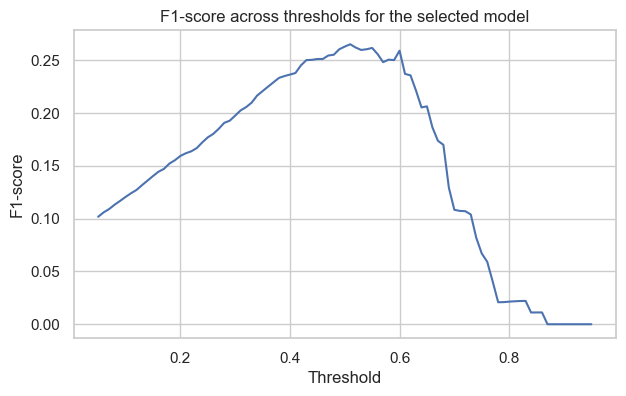

In [93]:
if RUN_GRID_SEARCH and selected_model_name in tuned_threshold_store:
    selected_threshold_df = tuned_threshold_store[selected_model_name]
else:
    selected_threshold_df = threshold_table_store[selected_model_name]

display(
    selected_threshold_df
    .sort_values("F1", ascending=False)
    .head(10)
)

plt.figure(figsize=(7, 4))
plt.plot(selected_threshold_df["Threshold"], selected_threshold_df["F1"])
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score across thresholds for the selected model")
plt.show()

## 8.3 Final internal test evaluation

The selected model is refit on the full training split and evaluated once on the untouched internal test set.

Classification report on internal test set:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       852
           1       0.18      0.62      0.27        45

    accuracy                           0.84       897
   macro avg       0.58      0.73      0.59       897
weighted avg       0.94      0.84      0.88       897



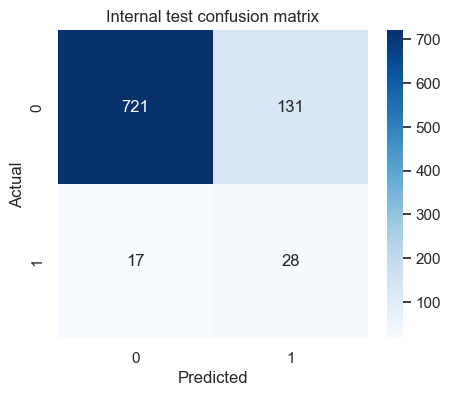

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.835006,0.176101,0.622222,0.27451,0.835994,0.231415


In [95]:
final_model = clone(selected_model_template)
final_model.fit(X_train_full, y_train_full)

test_scores = get_positive_scores(final_model, X_test)
test_predictions = (test_scores >= selected_threshold).astype(int)

print("Classification report on internal test set:")
print(classification_report(y_test, test_predictions, zero_division=0))

cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Internal test confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

final_test_metrics = {
    "Accuracy": accuracy_score(y_test, test_predictions),
    "Precision": precision_score(y_test, test_predictions, zero_division=0),
    "Recall": recall_score(y_test, test_predictions, zero_division=0),
    "F1": f1_score(y_test, test_predictions, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, test_scores),
    "PR_AUC": average_precision_score(y_test, test_scores),
}

display(pd.DataFrame([final_test_metrics]))

## 8.4 ROC curve and precision-recall curve

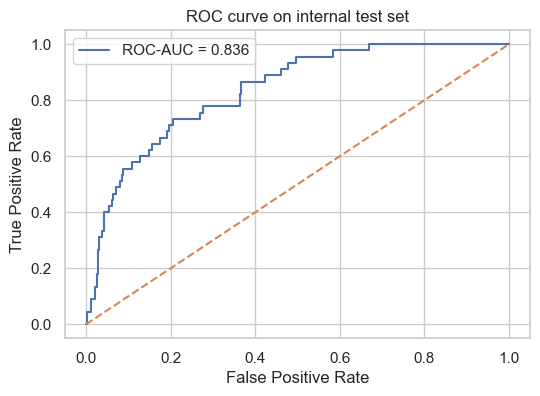

In [101]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_scores)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {final_test_metrics['ROC_AUC']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve on internal test set")
plt.legend()
plt.show()

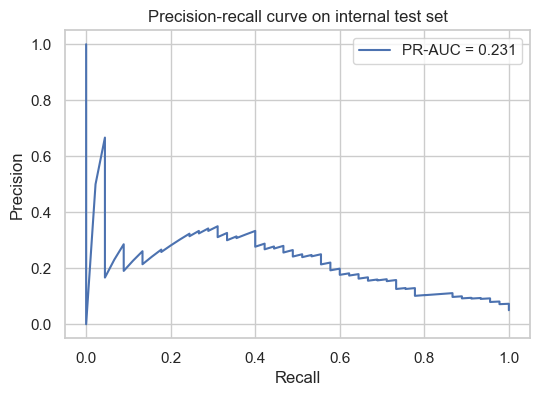

In [103]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, test_scores)

plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {final_test_metrics['PR_AUC']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curve on internal test set")
plt.legend()
plt.show()

## 8.5 Feature importance or coefficients

This section helps interpret the final model.

The interpretation depends on the final model type:

- Logistic Regression: coefficients are shown
- Tree-based models: feature importances are shown

These values describe contribution to model predictions, not causation.

,Feature,Coefficient,Absolute coefficient
0,num__age,1.136799,1.136799
3,num__medical_risk_count,0.156612,0.156612
1,num__avg_glucose_level,0.145881,0.145881
21,cat__smoking_status_never smoked,-0.072801,0.072801
17,cat__Residence_type_Rural,0.000000,0.000000
29,cat__bmi_group_normal_bmi,0.000000,0.000000
28,cat__bmi_group_low_bmi,0.000000,0.000000
27,cat__bmi_group_high_bmi,0.000000,0.000000
26,cat__age_group_young_adult,0.000000,0.000000
25,cat__age_group_older_adult,0.000000,0.000000


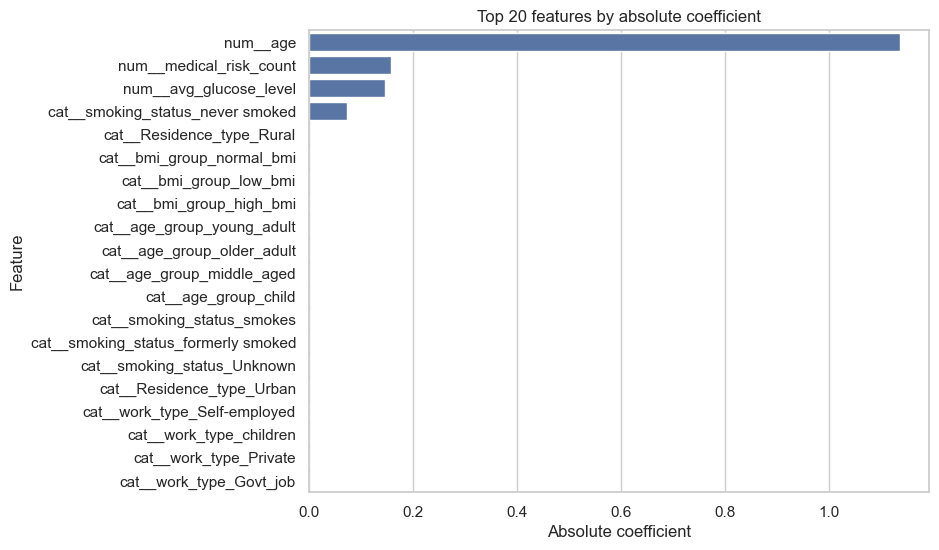

In [106]:
try:
    preprocessor_step = final_model.named_steps["preprocessor"]
    classifier_step = final_model.named_steps["classifier"]
    feature_names = preprocessor_step.get_feature_names_out()

    if hasattr(classifier_step, "coef_"):
        coefficients = classifier_step.coef_[0]

        coef_df = pd.DataFrame({
            "Feature": feature_names,
            "Coefficient": coefficients,
            "Absolute coefficient": np.abs(coefficients),
        }).sort_values("Absolute coefficient", ascending=False)

        display(coef_df.head(20))

        plt.figure(figsize=(8, 6))
        sns.barplot(data=coef_df.head(20), x="Absolute coefficient", y="Feature")
        plt.title("Top 20 features by absolute coefficient")
        plt.show()

    elif hasattr(classifier_step, "feature_importances_"):
        importances = classifier_step.feature_importances_

        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances,
        }).sort_values("Importance", ascending=False)

        display(importance_df.head(20))

        plt.figure(figsize=(8, 6))
        sns.barplot(data=importance_df.head(20), x="Importance", y="Feature")
        plt.title("Top 20 feature importances")
        plt.show()

    else:
        print("The selected model does not expose coefficients or feature importances.")

except Exception as error:
    print("Feature interpretation could not be produced for this model.")
    print(error)